In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)
device

In [ ]:
batch_size = 128
data_transform = transforms.Compose([
    transforms.ToTensor()
])

In [ ]:
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=data_transform
)

In [ ]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

In [ ]:
class AutoEncoder(nn.Module):

    def __init__(self, latent_dim: int = 16):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def forward(self, x):

        z = self.encoder(x)

        x_reconstructed = self.decoder(z)

        return x_reconstructed

In [ ]:
model = AutoEncoder().to(device)
model

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
epochs = 5

model.train()

for epoch in range(epochs):

    total_loss = 0

    for x, _ in train_loader:

        x = x.view(-1, 784).to(device)

        optimizer.zero_grad()

        x_reconstructed = model(x)

        loss = criterion(x_reconstructed, x)

        loss.backward()

        optimizer.step()

        total_loss = total_loss + loss.item()

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch + 1}/{epochs}   Loss = {avg_loss:.6f}")

Epoch 1/5   Loss = 0.056890
Epoch 2/5   Loss = 0.030756
Epoch 3/5   Loss = 0.025817
Epoch 4/5   Loss = 0.022938
Epoch 5/5   Loss = 0.020919


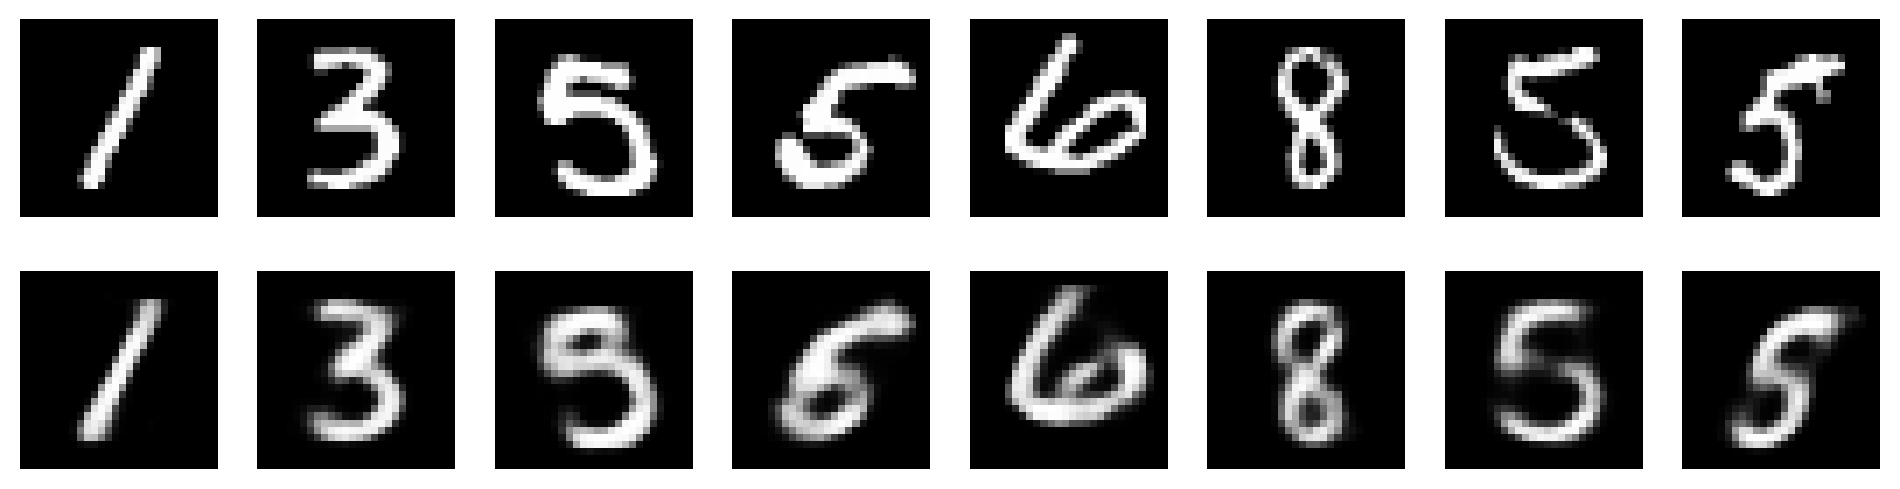

In [ ]:
model.eval()

with torch.no_grad():

    X, _ = next(iter(train_loader))

    X = X.view(-1, 784).to(device)

    X_reconstructed = model(X)

    n = 8

    X = X.cpu()
    X_reconstructed = X_reconstructed.cpu()

    plt.figure(figsize=(12, 3))

    for i in range(n):
        plt.subplot(2, n, i +1)
        plt.imshow(X[i].view(28, 28), cmap="gray")
        plt.axis("off")
        plt.subplot(2, n, i+1+n)
        plt.imshow(X_reconstructed[i].view(28, 28), cmap="gray")
        plt.axis("off")
    plt.show()